# Getting Started with GEOPE

This notebook walks through a minimal example of using **GEOPE** (Geodesic Pulse Engineering) to synthesise a quantum gate.

We will:
1. Define a target unitary (the Hadamard gate on 1 qubit).
2. Build the Lie algebra basis.
3. Run the GEOPE optimiser.
4. Check the result.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from geope import (
    GeopeEngine,
    Geope,
    Hamiltonian,
    construct_full_pauli_basis,
    construct_restricted_pauli_basis,
    multimatmul,
    fidelity
)

## 1. Define the target unitary

We target the **Hadamard gate**, a single-qubit gate that maps $|0\rangle \to |+\rangle$ and $|1\rangle \to |-\rangle$:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

In [2]:
target = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
print("Target unitary (Hadamard):")
print(target)

Target unitary (Hadamard):
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


## 2. Build the Pauli bases

For a single qubit the full Pauli basis is $\{\sigma_x, \sigma_y, \sigma_z\}$ (excluding identity). GEOPE uses this as the Lie algebra generators from which unitaries are constructed via the matrix exponential, a single time step expression of the unitary is:

$$U(\boldsymbol{\phi}) = \exp\!\bigl(i \sum_k \phi_k \sigma_k\bigr)$$

A restricted Pauli basis is constructed by the `construct_restricted_pauli_basis(n, restriction)` function. This function can takes the number of spins (`n`) and either a list of interaction strings (e.g. `['x', 'y']` or for 2-qubit terms `['xx', 'yy']`) or a dictionary mapping qubit labels to interaction strings (e.g. `{1: ['x', 'y'], 2: ['x', 'y'], (1,2): ['zz']}` if there were two qubits with an Ising interaction term). The labels `'x'`, `'y'`, and `'z'` refer to Pauli spin matrices $\sigma^x$, $\sigma^y$, and $\sigma^z$. 

The restricted Pauli basis is used to construct the control basis (`projected_basis`) and the drift basis (`drift_basis`).

In this case, we have control of local x and y fields, and there is a drift z term, giving Hamiltonian:

$$ H = \sigma^z + h_x(t) \sigma^x + h_y(t) \sigma^y.$$

The drift parameter is defined to be 1. This is also the default value for drift parameters if they are not specified. 

The initial parameters are set to be 1. The default value are random parameters – see the documentation for details.

In [3]:
nqubits = 1
basis = construct_full_pauli_basis(nqubits)
projected_basis = construct_restricted_pauli_basis(nqubits, {1: ['x', 'y']})
drift_basis = construct_restricted_pauli_basis(nqubits, {1: ['z']})
init_parameters = [0.5, -0.5]
drift_parameters = [1.]

print(f"Number of qubits:       {nqubits}")
print(f"Hilbert space dim:      {basis.dim}")
print(f"Lie algebra dim:        {basis.lie_algebra_dim}")
print(f"Basis labels:           {basis.labels}")
print(f"Projected basis labels: {projected_basis.labels}")
print(f"Drift basis labels:     {drift_basis.labels}")

Number of qubits:       1
Hilbert space dim:      2
Lie algebra dim:        3
Basis labels:           ['X', 'Y', 'Z']
Projected basis labels: ['X', 'Y']
Drift basis labels:     ['Z']


## 3. Create the engine and optimiser

The `GeopeEngine` precompiles the JAX functions (unitary computation, Jacobian, geodesic Hamiltonian, fidelity). `Geope` wraps the engine with an optimisation loop.

The number of piecewise steps is set in the `GeopeEngine`.

In [4]:
engine = GeopeEngine(
    target_unitary=target,
    full_basis=basis,
    projected_basis=projected_basis,
    drift_basis=drift_basis,
    piecewise_steps=3
)

opt = Geope(
    engine=engine,
    init_parameters=init_parameters,
    drift_parameters=drift_parameters,
    max_steps=200,
    max_step_size=0.9,
    precision=0.9999999,
    verbose=True,
    seed=42,
)

## 4. Run the optimisation

`optimize()` runs the geodesic update loop. Each step:
1. Computes the geodesic Hamiltonian pointing from the current unitary towards the target.
2. Projects it onto the controllable basis to find the optimal parameter update direction.
3. Performs a line search along that direction.

The method returns `True` if the target precision is reached.

In [5]:
success = opt.optimize()
print(f"\nConverged: {success}")
print(f"Steps:       {opt.steps[-1]}")
print(f"Fidelity:    {opt.fidelities[-1]}")
print(f"Final parameters: {opt.parameters[-1]}")

[4/200] [Fidelity = 0.999999999983874] A solution!                                                                      

Converged: True
Steps:       4
Fidelity:    0.999999999983874
Final parameters: [[ 1.107527   -0.61167785  1.        ]
 [ 0.66549443 -1.1386477   1.        ]
 [ 0.79323502 -0.51359499  1.        ]]


## 5. Check the result

### Convergence plot

The fidelity should climb rapidly towards 1.

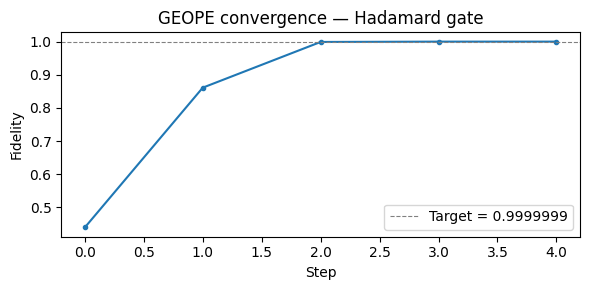

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(opt.steps, opt.fidelities, "o-", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Fidelity")
ax.set_title("GEOPE convergence — Hadamard gate")
ax.axhline(opt.precision, color="grey", linestyle="--", linewidth=0.8, label=f"Target = {opt.precision}")
ax.legend()
plt.tight_layout()
plt.show()

### Recovered parameters

The optimised Lie-algebra coefficients $\boldsymbol{\phi}$ define the Hamiltonian whose exponential gives the target gate.

In [7]:
final_params = opt.parameters[-1]
print("Optimised parameters:")
for t, param_step in enumerate(final_params):
    print(f"--\nTime step {t}")
    for label, phi in zip(basis.labels, param_step):
        print(f"\t{label}: {phi:.6f}")

Optimised parameters:
--
Time step 0
	X: 1.107527
	Y: -0.611678
	Z: 1.000000
--
Time step 1
	X: 0.665494
	Y: -1.138648
	Z: 1.000000
--
Time step 2
	X: 0.793235
	Y: -0.513595
	Z: 1.000000


### Verify the synthesised unitary

Reconstruct the unitary from the optimised parameters and compare it to the target. We find the target unitary up to global phase.

In [8]:
Us = [Hamiltonian(basis, param_step).unitary.matrix for param_step in final_params]
unitary_matrix = multimatmul(Us[::-1]) # Note the order is reversed since the full unitary is U_2 U_1 U_0

print("Synthesised unitary:")
print(unitary_matrix)

print("\nTarget unitary:")
print(target)

fid = fidelity(unitary_matrix, target)
print(f"\nFidelity: {fid}")

Synthesised unitary:
[[ 5.43007304e-06-0.70710785j -6.92167273e-07-0.70710571j]
 [ 6.92167273e-07-0.70710571j  5.43007304e-06+0.70710785j]]

Target unitary:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]

Fidelity: 0.9999999999838738
